# Task 1 — Hypotheses H1–H5

Standalone notebook; logic aligned with `src/hypotheses_task1.py`. Run top to bottom.


## Setup & load


In [1]:
from pathlib import Path
import os
# Repo root whether kernel cwd is repo or notebooks/
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
import warnings
warnings.filterwarnings("ignore")
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu
from statsmodels.nonparametric.smoothers_lowess import lowess

QUIZ1_PATH = REPO_ROOT / "data/quiz1/quiz1_marks.csv"
QUIZ2_PATH = REPO_ROOT / "data/quiz2/quiz2_marks.csv"
QUIZ3_PATH = REPO_ROOT / "data/quiz3/quiz3_marks.csv"
OUT_DIR = REPO_ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

C1, C2, C3 = "#2E86AB", "#E84855", "#F4A261"
COLORS = [C1, C2, C3]
SUCCESS = "#22C55E"

def parse_time_to_seconds(text) -> float:
    if pd.isna(text): return np.nan
    s = str(text).strip()
    if s in ("-", ""): return np.nan
    sl, total = s.lower(), 0.0
    for pat, mul in [(r"(\d+)\s*days?", 86400), (r"(\d+)\s*hours?", 3600), (r"(\d+)\s*mins?", 60), (r"(\d+)\s*secs?", 1)]:
        m = re.search(pat, sl)
        if m: total += int(m.group(1)) * mul
    return total if total > 0 else np.nan

def time_sec_to_minutes(time_sec: pd.Series) -> pd.Series:
    s = time_sec.astype(float)
    as_sec, as_ms = s / 60.0, s / 60_000.0
    use_ms = (as_sec > 720.0) & (as_ms <= 720.0) & (as_sec < 10_000.0)
    return pd.Series(np.where(use_ms, as_ms, as_sec), index=time_sec.index, dtype=float)

def load_quiz(path: Path, quiz_id: int) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df[df["State"] == "Finished"].copy()
    df["grade"] = pd.to_numeric(df["Grade/10.00"], errors="coerce")
    df["time_sec"] = df["Time taken"].apply(parse_time_to_seconds)
    df["time_min"] = time_sec_to_minutes(df["time_sec"])
    q_cols = [c for c in df.columns if c.startswith("Q.")]
    for c in q_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.rename(columns={"Student Code": "student_id"})
    df["quiz"] = quiz_id
    started = df["Started on"].astype(str).str.replace(r"\s+", " ", regex=True)
    df["started_on"] = pd.to_datetime(started, errors="coerce", dayfirst=True, format="mixed")
    df = df.sort_values(["student_id", "started_on"])
    df["attempt_no"] = df.groupby("student_id").cumcount() + 1
    keep = ["student_id", "quiz", "attempt_no", "grade", "time_sec", "time_min", "started_on"] + q_cols
    return df[keep].dropna(subset=["grade", "time_sec"]).reset_index(drop=True)

def triplets(q1, q2, q3):
    return [(q1, "Quiz 1"), (q2, "Quiz 2"), (q3, "Quiz 3")]

def get_q_cols(df):
    return [c for c in df.columns if c.startswith("Q.")]

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

q1, q2, q3 = load_quiz(QUIZ1_PATH, 1), load_quiz(QUIZ2_PATH, 2), load_quiz(QUIZ3_PATH, 3)
print("Loaded", len(q1), len(q2), len(q3))


Loaded 13911 10430 8066


## H1 → `h1_time_vs_score.png`


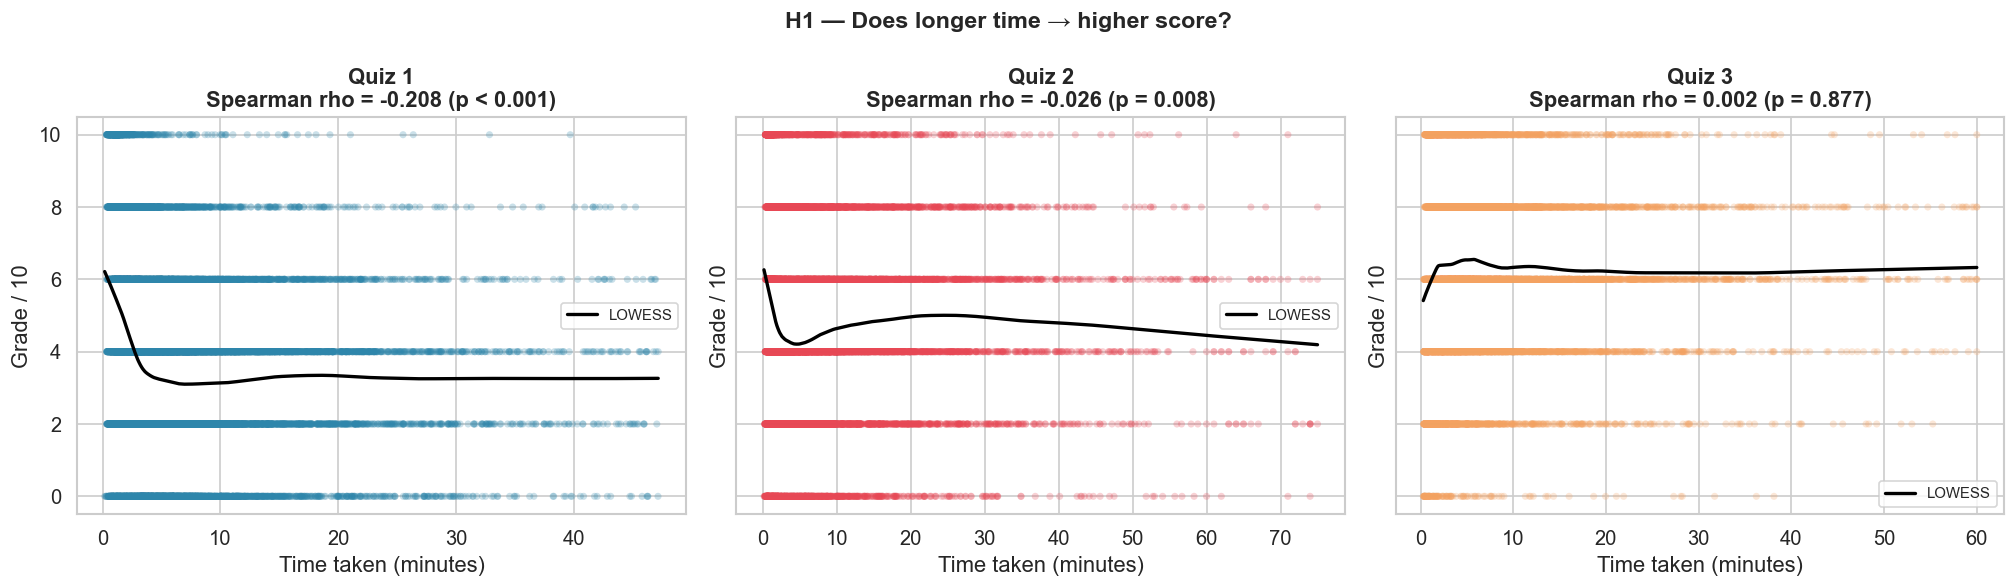

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, (df, label), color in zip(axes, triplets(q1, q2, q3), COLORS):
    cap = df["time_min"].quantile(0.97)
    d = df[df["time_min"] <= cap].copy()
    rho, pval = spearmanr(d["time_min"], d["grade"])
    ax.scatter(d["time_min"], d["grade"], alpha=0.25, s=18, color=color, edgecolors="none")
    sm = lowess(d["grade"], d["time_min"], frac=0.3)
    ax.plot(sm[:, 0], sm[:, 1], color="black", linewidth=2, label="LOWESS")
    ptxt = "< 0.001" if pval < 0.001 else f"= {pval:.3f}"
    ax.set_title(f"{label}\nSpearman rho = {rho:.3f} (p {ptxt})", fontweight="bold")
    ax.set_xlabel("Time taken (minutes)")
    ax.set_ylabel("Grade / 10")
    ax.legend(fontsize=9)
plt.suptitle("H1 — Does longer time → higher score?", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "h1_time_vs_score.png", bbox_inches="tight")
plt.show()


## H2 → `h2_question_difficulty.png`


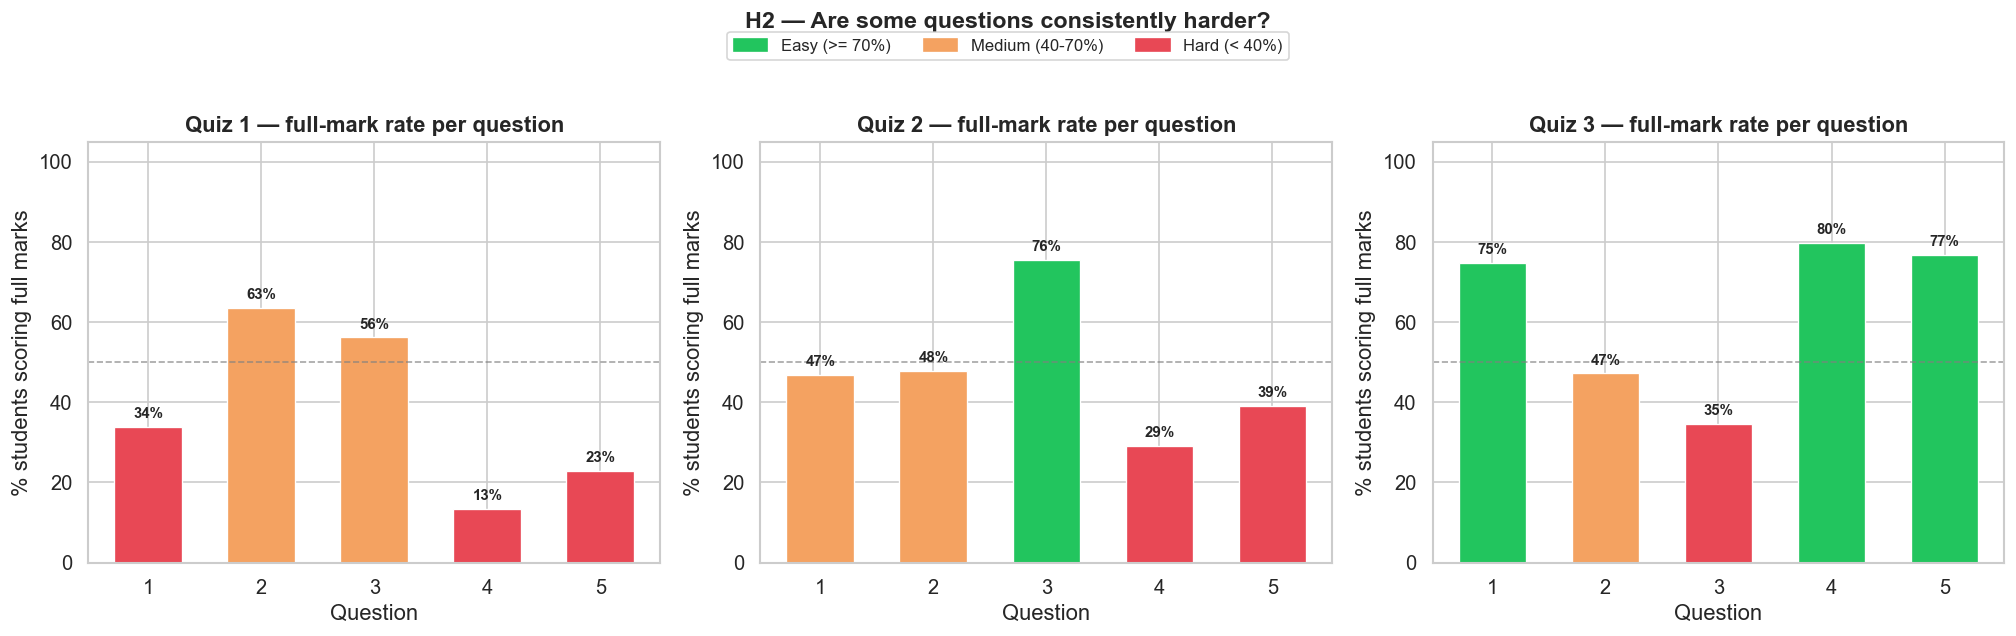

In [3]:
def q_difficulty(df):
    rates = {}
    for c in get_q_cols(df):
        try: mx = float(c.split("/")[1])
        except (IndexError, ValueError): mx = float(df[c].max())
        qid = c.split()[1].rstrip(".")
        rates[qid] = (df[c] == mx).mean() * 100
    return rates

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (df, label) in zip(axes, triplets(q1, q2, q3)):
    cr = q_difficulty(df)
    qs, vals = list(cr.keys()), list(cr.values())
    bar_colors = [SUCCESS if v >= 70 else C3 if v >= 40 else C2 for v in vals]
    bars = ax.bar(qs, vals, color=bar_colors, edgecolor="white", linewidth=0.8, width=0.6)
    ax.set_ylim(0, 105)
    ax.set_title(f"{label} — full-mark rate per question", fontweight="bold")
    ax.set_xlabel("Question")
    ax.set_ylabel("% students scoring full marks")
    ax.axhline(50, color="grey", linestyle="--", linewidth=1, alpha=0.7)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"{v:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
patches = [mpatches.Patch(color=SUCCESS, label="Easy (>= 70%)"), mpatches.Patch(color=C3, label="Medium (40-70%)"), mpatches.Patch(color=C2, label="Hard (< 40%)")]
fig.legend(handles=patches, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.04), fontsize=10)
plt.suptitle("H2 — Are some questions consistently harder?", fontsize=14, fontweight="bold", y=1.06)
plt.tight_layout()
fig.savefig(OUT_DIR / "h2_question_difficulty.png", bbox_inches="tight")
plt.show()


## H3 → `h3_improvement_by_tier.png`


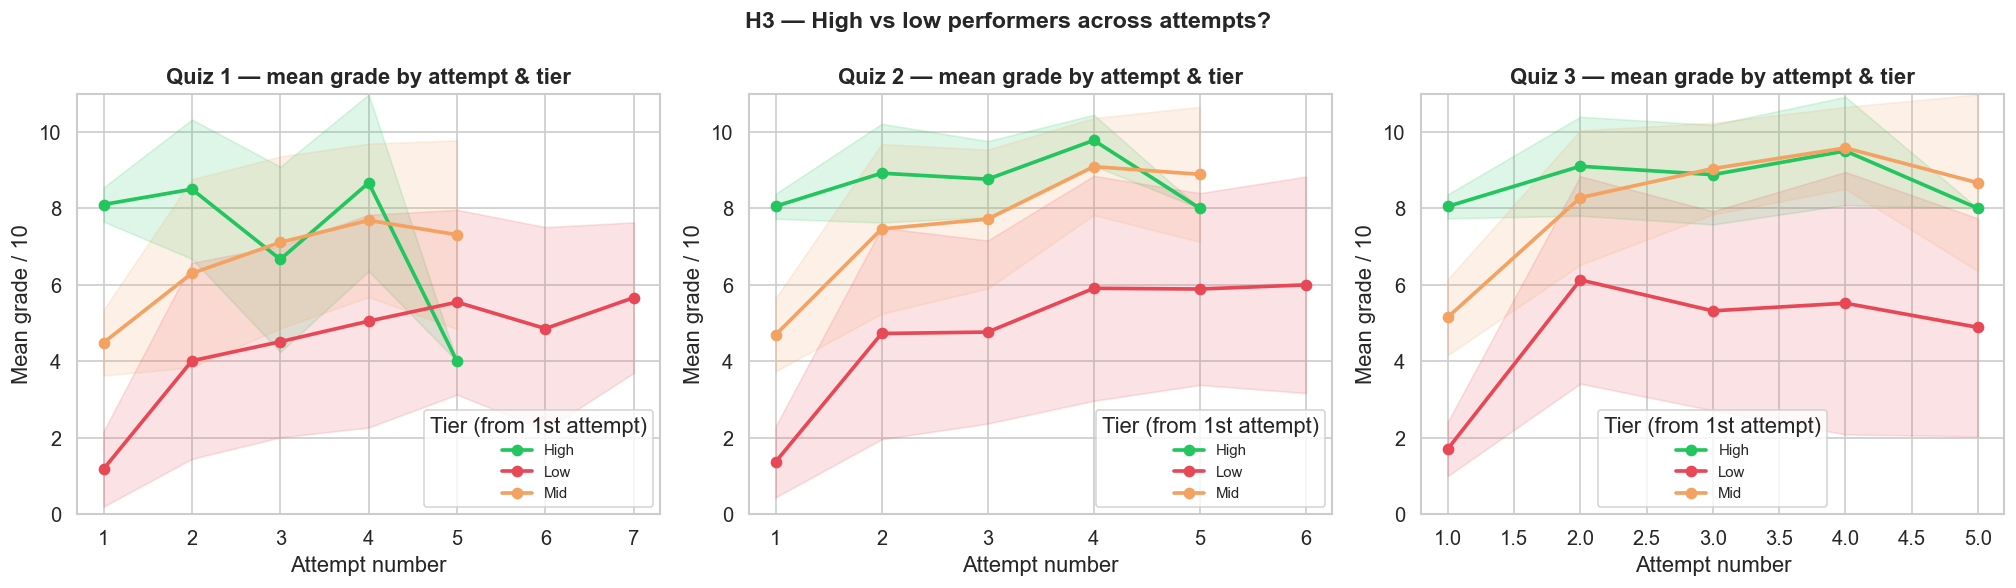

In [4]:
def tier_from_grade(g: float) -> str:
    return "High" if g >= 7 else ("Mid" if g >= 4 else "Low")

TIER_COLORS = {"High": SUCCESS, "Mid": C3, "Low": C2}
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (df, label) in zip(axes, triplets(q1, q2, q3)):
    multi = df[df.groupby("student_id")["attempt_no"].transform("max") >= 2]
    if multi.empty:
        ax.set_title(f"{label} — no multi-attempt students")
        continue
    first_g = multi.sort_values(["student_id", "attempt_no"]).groupby("student_id", as_index=False).first()[["student_id", "grade"]].rename(columns={"grade": "first_grade"})
    first_g["tier"] = first_g["first_grade"].map(tier_from_grade)
    multi = multi.merge(first_g[["student_id", "tier"]], on="student_id")
    agg = multi.groupby(["tier", "attempt_no"])["grade"].agg(["mean", "std"]).reset_index()
    agg["std"] = agg["std"].fillna(0)
    for tier, grp in agg.groupby("tier"):
        ax.plot(grp["attempt_no"], grp["mean"], marker="o", linewidth=2.2, color=TIER_COLORS[tier], label=tier)
        ax.fill_between(grp["attempt_no"], grp["mean"] - grp["std"], grp["mean"] + grp["std"], alpha=0.15, color=TIER_COLORS[tier])
    ax.set_title(f"{label} — mean grade by attempt & tier", fontweight="bold")
    ax.set_xlabel("Attempt number")
    ax.set_ylabel("Mean grade / 10")
    ax.set_ylim(0, 11)
    ax.legend(title="Tier (from 1st attempt)", fontsize=9)
plt.suptitle("H3 — High vs low performers across attempts?", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "h3_improvement_by_tier.png", bbox_inches="tight")
plt.show()


## H4 part A → `h4_difficulty_perf_heatmap.png`


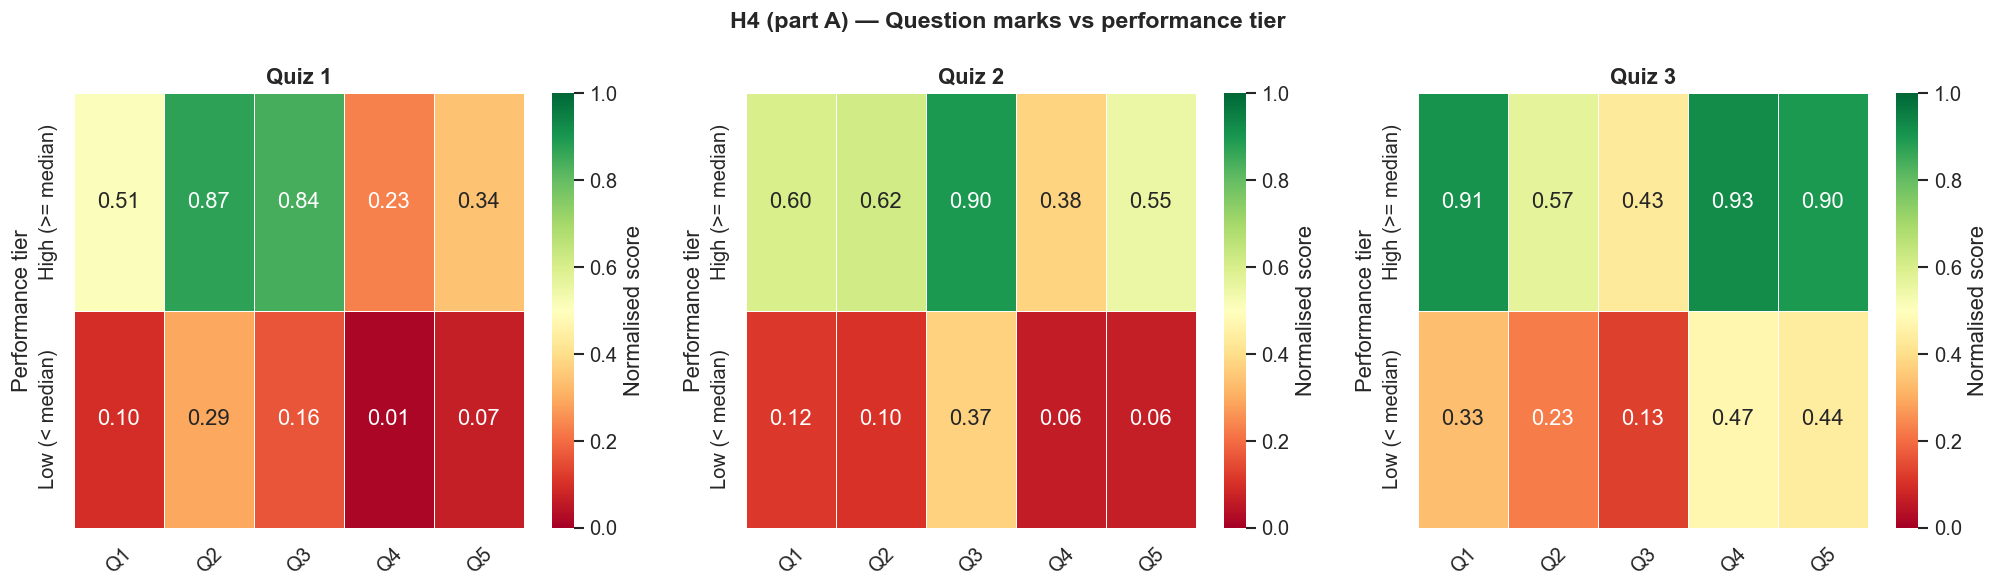

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (df, label) in zip(axes, triplets(q1, q2, q3)):
    d = df.copy()
    d["perf_tier"] = np.where(d["grade"] >= d["grade"].median(), "High (>= median)", "Low (< median)")
    qc = get_q_cols(df)
    agg = d.groupby("perf_tier")[qc].mean()
    for c in qc:
        try: mx = float(c.split("/")[1])
        except: mx = float(d[c].max())
        agg[c] = agg[c] / mx
    agg.columns = [f"Q{c.split()[1].rstrip('.')}" for c in qc]
    sns.heatmap(agg, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5, ax=ax, cbar_kws={"label": "Normalised score"})
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("Performance tier")
    ax.tick_params(axis="x", rotation=45)
plt.suptitle("H4 (part A) — Question marks vs performance tier", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "h4_difficulty_perf_heatmap.png", bbox_inches="tight")
plt.show()


## H4 part B → `h4_mean_total_time_by_question_median_split.png`


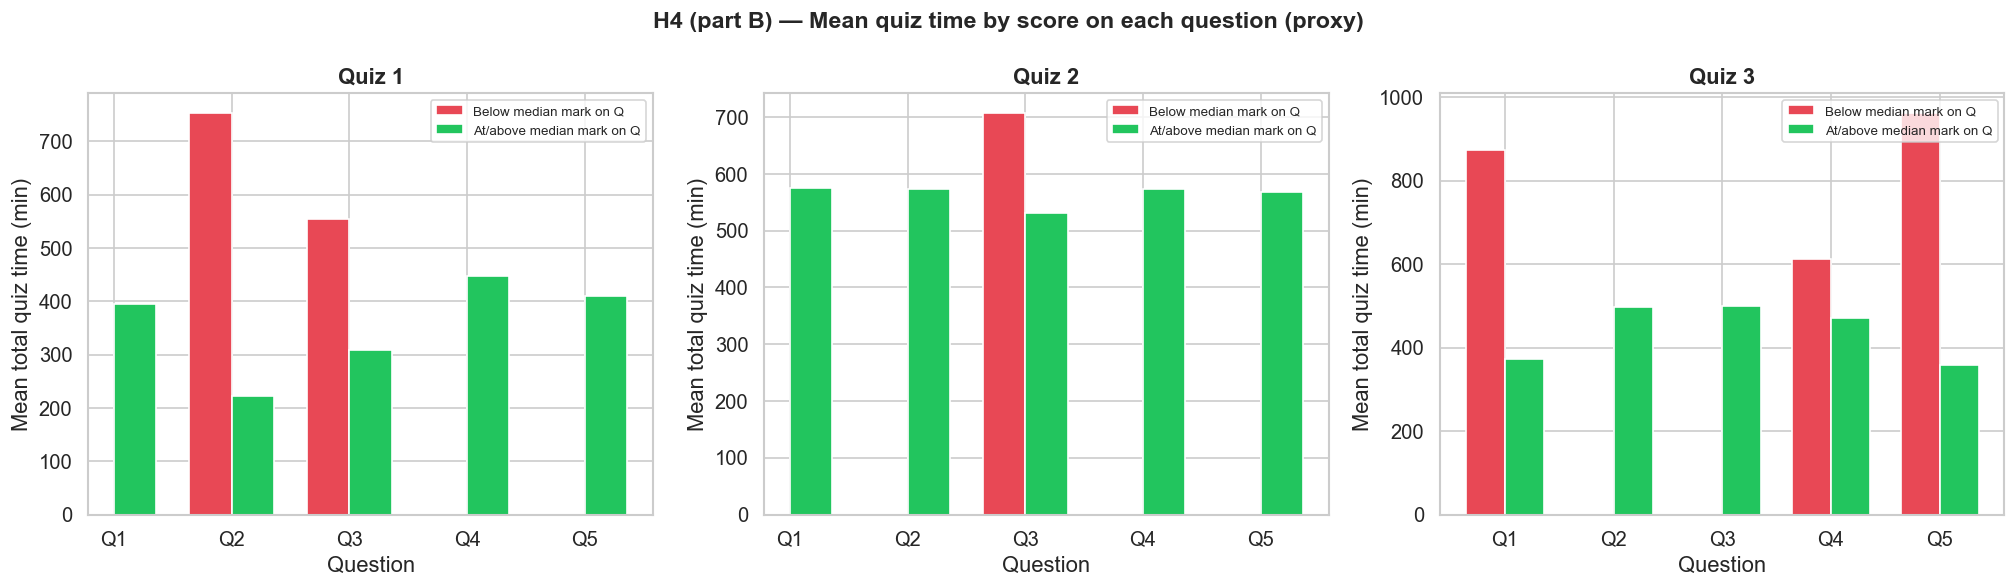

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (df, label) in zip(axes, triplets(q1, q2, q3)):
    qc = get_q_cols(df)
    below_means, above_means, x_labels = [], [], []
    for c in qc:
        qid = f"Q{c.split()[1].rstrip('.')}"
        x_labels.append(qid)
        med = df[c].median()
        below_means.append(df[df[c] < med]["time_min"].mean())
        above_means.append(df[df[c] >= med]["time_min"].mean())
    x = np.arange(len(x_labels))
    w = 0.36
    ax.bar(x - w / 2, below_means, width=w, label="Below median mark on Q", color=C2, edgecolor="white")
    ax.bar(x + w / 2, above_means, width=w, label="At/above median mark on Q", color=SUCCESS, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Question")
    ax.set_ylabel("Mean total quiz time (min)")
    ax.legend(fontsize=8, loc="upper right")
plt.suptitle("H4 (part B) — Mean quiz time by score on each question (proxy)", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "h4_mean_total_time_by_question_median_split.png", bbox_inches="tight")
plt.show()


## H4 part C → `h4_grade_time_scatter_by_tier.png`


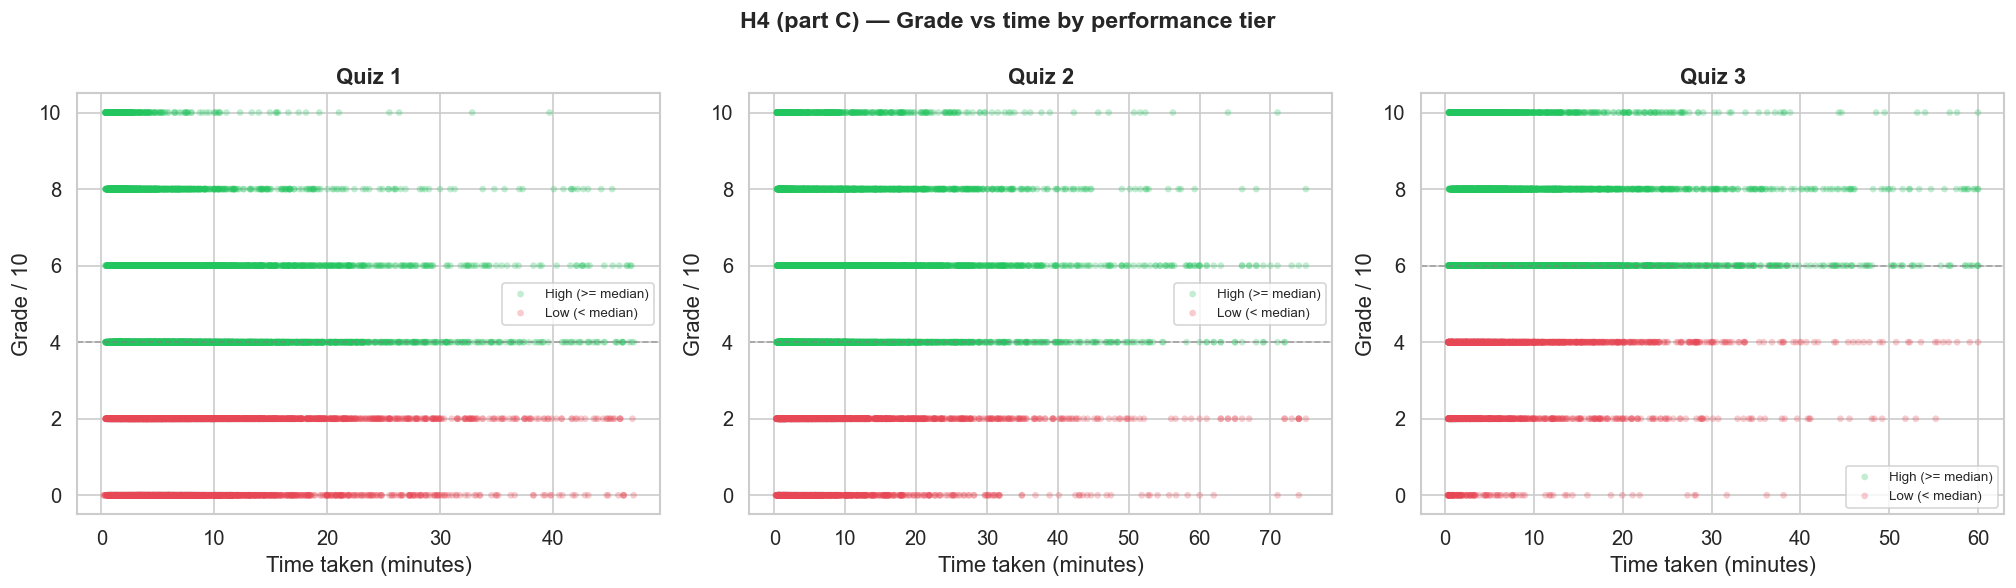

In [7]:
scatter_pal = {"High (>= median)": SUCCESS, "Low (< median)": C2}
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (df, label) in zip(axes, triplets(q1, q2, q3)):
    cap = df["time_min"].quantile(0.97)
    d = df[df["time_min"] <= cap].copy()
    d["perf_tier"] = np.where(d["grade"] >= d["grade"].median(), "High (>= median)", "Low (< median)")
    for tier, color in scatter_pal.items():
        sub = d[d["perf_tier"] == tier]
        ax.scatter(sub["time_min"], sub["grade"], alpha=0.28, s=16, color=color, edgecolors="none", label=tier)
    ax.axhline(d["grade"].median(), color="grey", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Time taken (minutes)")
    ax.set_ylabel("Grade / 10")
    ax.legend(fontsize=8)
plt.suptitle("H4 (part C) — Grade vs time by performance tier", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "h4_grade_time_scatter_by_tier.png", bbox_inches="tight")
plt.show()


## H4 part D → `h4_time_vs_perf_violin.png`


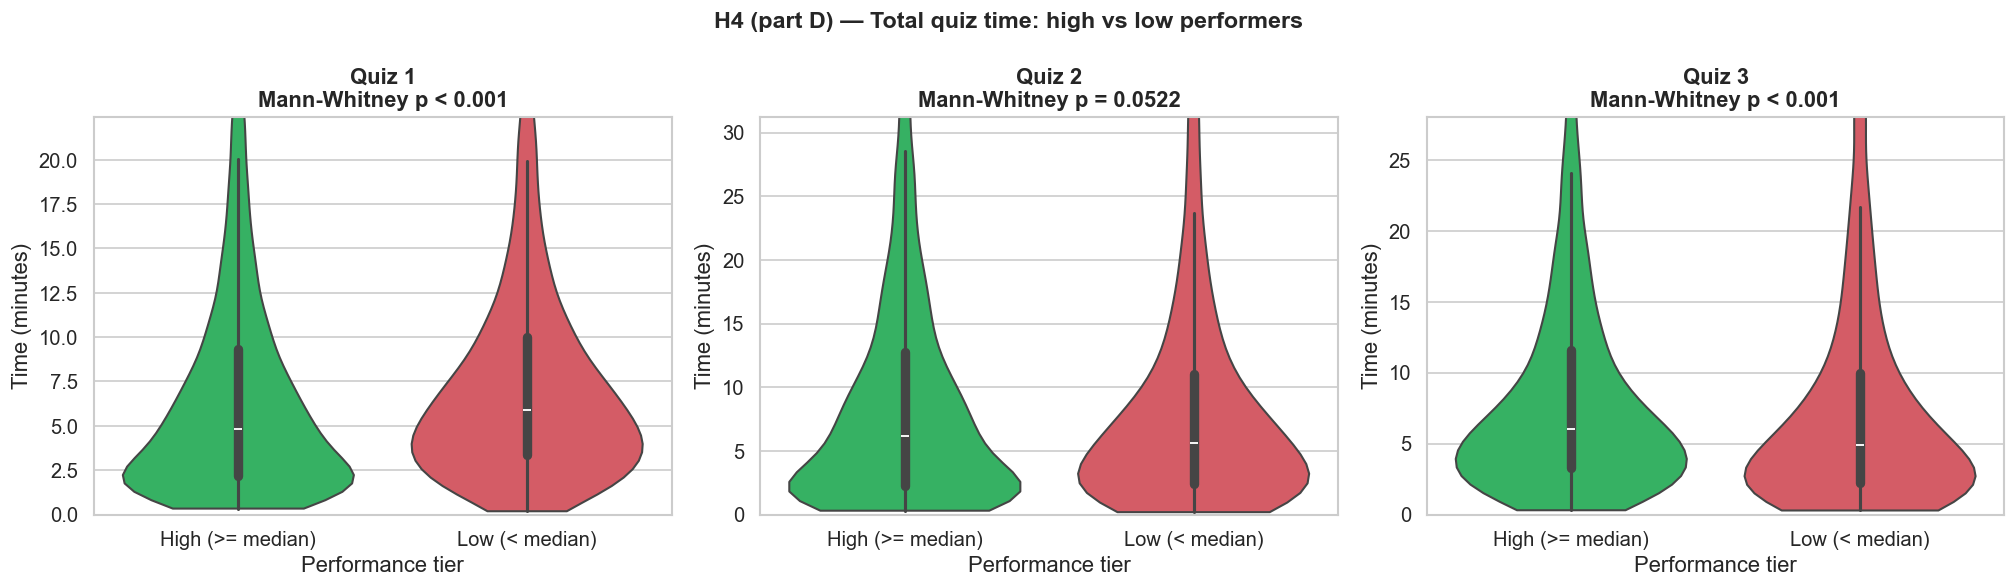

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (df, label) in zip(axes, triplets(q1, q2, q3)):
    d = df.copy()
    d["perf_tier"] = np.where(d["grade"] >= d["grade"].median(), "High (>= median)", "Low (< median)")
    high_t = d[d["perf_tier"] == "High (>= median)"]["time_min"].dropna()
    low_t = d[d["perf_tier"] == "Low (< median)"]["time_min"].dropna()
    _, p_mw = mannwhitneyu(high_t, low_t, alternative="two-sided")
    cap = df["time_min"].quantile(0.97)
    d_plot = d[d["time_min"] <= cap].copy()
    ymax = d_plot["time_min"].quantile(0.95)
    sns.violinplot(data=d_plot, x="perf_tier", y="time_min", hue="perf_tier", ax=ax, palette={"High (>= median)": SUCCESS, "Low (< median)": C2}, inner="box", cut=0, legend=False, dodge=False)
    ax.set_ylim(0, ymax * 1.02)
    ptxt = "< 0.001" if p_mw < 0.001 else f"= {p_mw:.4f}"
    ax.set_title(f"{label}\nMann-Whitney p {ptxt}", fontweight="bold")
    ax.set_xlabel("Performance tier")
    ax.set_ylabel("Time (minutes)")
plt.suptitle("H4 (part D) — Total quiz time: high vs low performers", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "h4_time_vs_perf_violin.png", bbox_inches="tight")
plt.show()


## H5 part A → `h5_optimal_time_window.png`


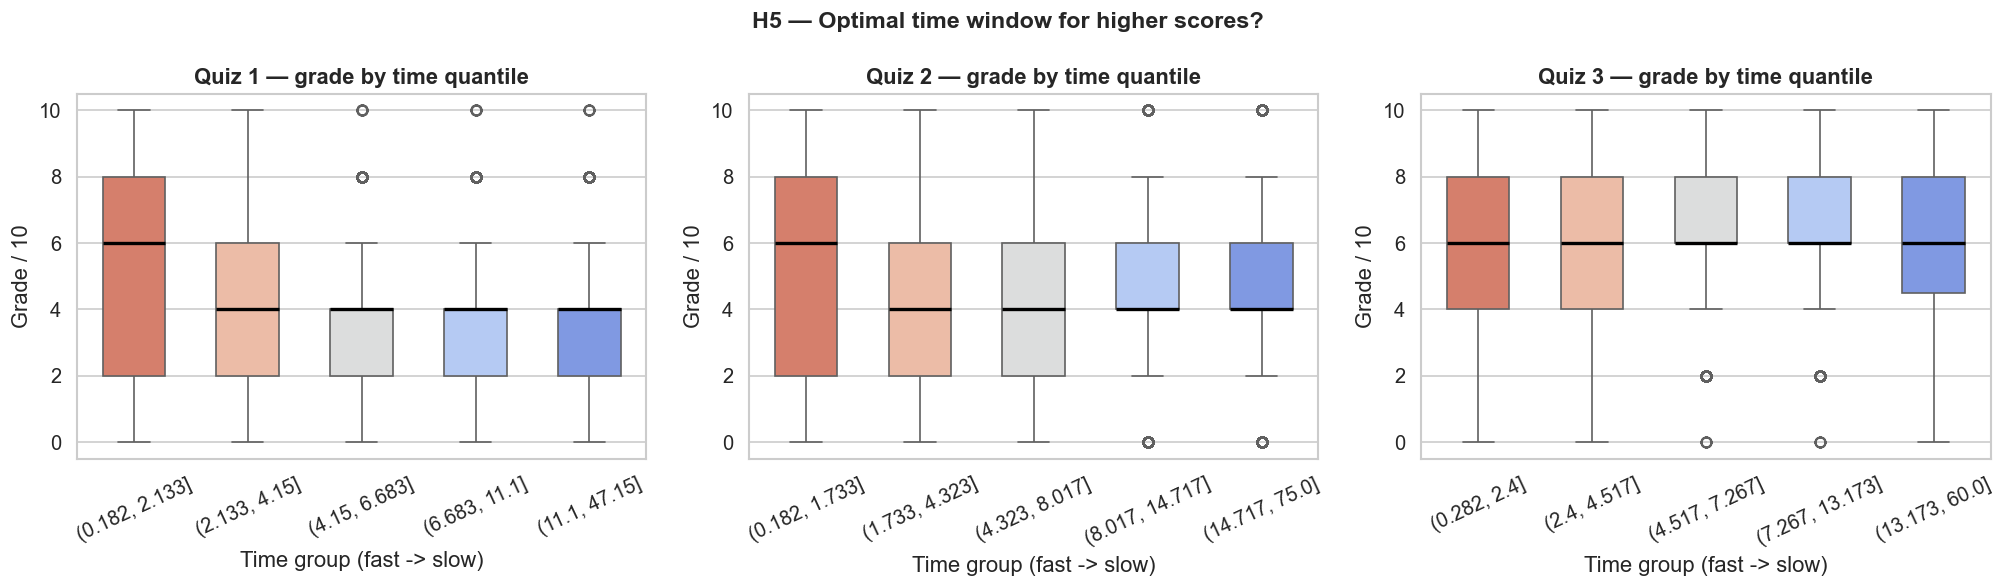

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (df, label) in zip(axes, triplets(q1, q2, q3)):
    cap = df["time_min"].quantile(0.97)
    d = df[df["time_min"] <= cap].copy()
    try:
        d["time_bin"] = pd.qcut(d["time_min"], q=5, duplicates="drop")
    except ValueError:
        ax.set_title(f"{label} — insufficient distinct times")
        continue
    bin_order = list(d["time_bin"].cat.categories)
    if len(bin_order) < 2:
        ax.set_title(f"{label} — not enough bins")
        continue
    pal_use = sns.color_palette("coolwarm_r", n_colors=len(bin_order))
    sns.boxplot(data=d, x="time_bin", y="grade", hue="time_bin", order=bin_order, palette=dict(zip(bin_order, pal_use)), ax=ax, width=0.55, medianprops=dict(color="black", linewidth=2), legend=False, dodge=False)
    ax.set_title(f"{label} — grade by time quantile", fontweight="bold")
    ax.set_xlabel("Time group (fast -> slow)")
    ax.set_ylabel("Grade / 10")
    ax.tick_params(axis="x", rotation=25)
plt.suptitle("H5 — Optimal time window for higher scores?", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "h5_optimal_time_window.png", bbox_inches="tight")
plt.show()


## H5 part B → `h5_grade_vs_time_lowess.png`


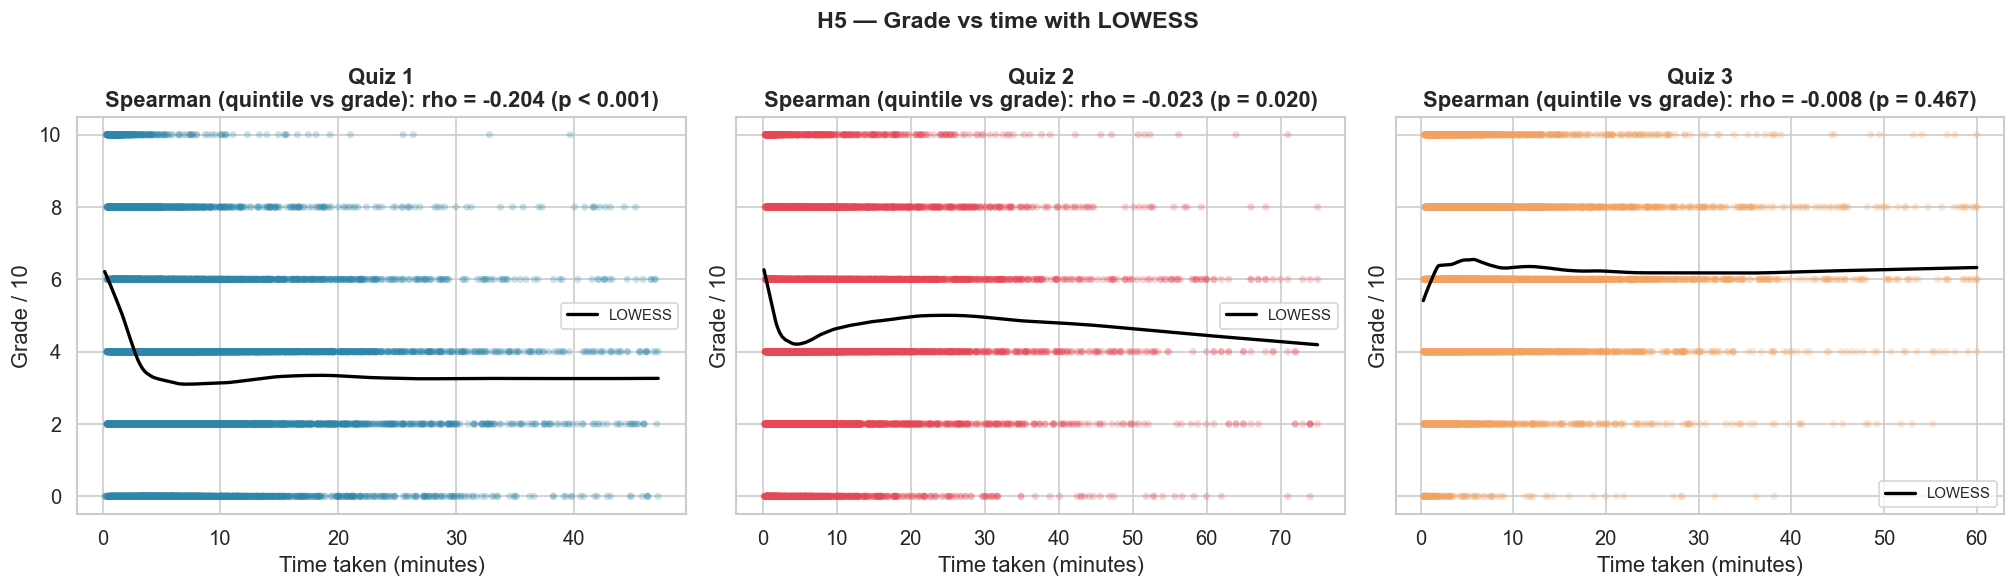

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, (df, label), color in zip(axes, triplets(q1, q2, q3), COLORS):
    cap = df["time_min"].quantile(0.97)
    d = df[df["time_min"] <= cap].copy()
    ax.scatter(d["time_min"], d["grade"], alpha=0.25, s=18, color=color, edgecolors="none")
    sm = lowess(d["grade"], d["time_min"], frac=0.3)
    ax.plot(sm[:, 0], sm[:, 1], color="black", linewidth=2, label="LOWESS")
    try:
        d["time_bin"] = pd.qcut(d["time_min"], q=5, duplicates="drop")
        codes = d["time_bin"].cat.codes
        valid = codes >= 0
        if valid.sum() >= 2 and codes[valid].nunique() >= 2:
            rho, p_sp = spearmanr(codes[valid], d.loc[valid, "grade"])
            ptxt = "< 0.001" if p_sp < 0.001 else f"= {p_sp:.3f}"
            ax.set_title(f"{label}\nSpearman (quintile vs grade): rho = {rho:.3f} (p {ptxt})", fontweight="bold")
        else:
            ax.set_title(label, fontweight="bold")
    except (ValueError, TypeError):
        ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Time taken (minutes)")
    ax.set_ylabel("Grade / 10")
    ax.legend(fontsize=9)
plt.suptitle("H5 — Grade vs time with LOWESS", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "h5_grade_vs_time_lowess.png", bbox_inches="tight")
plt.show()
